# Notebook 4 — Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on the training dataset only.

The goal is to understand:
- data types and structure
- missing values
- numerical distributions
- categorical variables
- relationships between features and the target
- date-related patterns
- potential outliers and unusual values

The validation and test sets are not used in this notebook to avoid data leakage.

The findings from this notebook will guide feature engineering and model selection in later steps.

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the final dataset created in Notebook 1
ml_table = pd.read_pickle("ml_table.pkl")

print("ML table shape:", ml_table.shape)
print("Unique orders:", ml_table["order_id"].nunique())

ml_table.head()

ML table shape: (99441, 32)
Unique orders: 99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,max_item_price,total_freight_value,mean_freight_value,mean_product_weight_g,product_category_count,seller_state_count,payment_count,total_payment_value,mean_payment_value,max_payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,8.72,500.0,1.0,1.0,3.0,38.71,12.903333,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,22.76,400.0,1.0,1.0,1.0,141.46,141.460000,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,19.22,420.0,1.0,1.0,1.0,179.12,179.120000,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,27.20,450.0,1.0,1.0,1.0,72.20,72.200000,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,8.72,250.0,1.0,1.0,1.0,28.62,28.620000,1.0


In [2]:
print("Columns:")
for i, col in enumerate(ml_table.columns, start=1):
    print(f"{i}. {col}")

print("\nData types:")
print(ml_table.dtypes)

Columns:
1. order_id
2. customer_id
3. order_status
4. order_purchase_timestamp
5. order_approved_at
6. order_delivered_carrier_date
7. order_delivered_customer_date
8. order_estimated_delivery_date
9. customer_unique_id
10. customer_zip_code_prefix
11. customer_city
12. customer_state
13. geolocation_zip_code_prefix
14. latitude
15. longitude
16. city
17. state
18. item_count
19. unique_products
20. unique_sellers
21. total_item_price
22. mean_item_price
23. max_item_price
24. total_freight_value
25. mean_freight_value
26. mean_product_weight_g
27. product_category_count
28. seller_state_count
29. payment_count
30. total_payment_value
31. mean_payment_value
32. max_payment_installments

Data types:
order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
orde

In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    ml_table[col] = pd.to_datetime(ml_table[col], errors="coerce")

print(ml_table[date_columns].dtypes)

print("\nMissing values in date columns:")
print(ml_table[date_columns].isnull().sum())

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Missing values in date columns:
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [4]:
# Create the late-delivery target
ml_table["is_late"] = (
    ml_table["order_delivered_customer_date"]
    > ml_table["order_estimated_delivery_date"]
).astype(int)

print("Target distribution:")
print(ml_table["is_late"].value_counts())

print("\nTarget proportions:")
print(ml_table["is_late"].value_counts(normalize=True))

Target distribution:
is_late
0    91614
1     7827
Name: count, dtype: int64

Target proportions:
is_late
0    0.92129
1    0.07871
Name: proportion, dtype: float64


In [5]:
status_analysis = pd.crosstab(
    ml_table["order_status"],
    ml_table["is_late"],
    normalize="index"
)

status_analysis["total_orders"] = ml_table["order_status"].value_counts()

status_analysis

is_late,0,1,total_orders
order_status,,,
approved,1.000000,0.000000,2
canceled,0.998400,0.001600,625
created,1.000000,0.000000,5
delivered,0.918883,0.081117,96478
invoiced,1.000000,0.000000,314
processing,1.000000,0.000000,301
shipped,1.000000,0.000000,1107
unavailable,1.000000,0.000000,609


In [6]:
# Keep only orders that were actually delivered
ml_table = ml_table.loc[
    ml_table["order_status"] == "delivered"
].copy()

print("Shape after keeping delivered orders:", ml_table.shape)

print("\nTarget distribution:")
print(ml_table["is_late"].value_counts())

print("\nTarget proportions:")
print(ml_table["is_late"].value_counts(normalize=True))

Shape after keeping delivered orders: (96478, 33)

Target distribution:
is_late
0    88652
1     7826
Name: count, dtype: int64

Target proportions:
is_late
0    0.918883
1    0.081117
Name: proportion, dtype: float64


In [7]:
missing_summary = pd.DataFrame({
    "missing_count": ml_table.isnull().sum(),
    "missing_percentage": (
        ml_table.isnull().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_percentage
latitude,264,0.27
geolocation_zip_code_prefix,264,0.27
state,264,0.27
city,264,0.27
longitude,264,0.27
mean_product_weight_g,16,0.02
order_approved_at,14,0.01
order_delivered_customer_date,8,0.01
order_delivered_carrier_date,2,0.00
payment_count,1,0.00


In [8]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

date_summary = pd.DataFrame({
    "earliest": ml_table[date_columns].min(),
    "latest": ml_table[date_columns].max(),
    "missing": ml_table[date_columns].isnull().sum()
})

date_summary

,earliest,latest,missing
order_purchase_timestamp,2016-09-15 12:16:38,2018-08-29 15:00:37,0
order_approved_at,2016-09-15 12:16:38,2018-08-29 15:10:26,14
order_delivered_carrier_date,2016-10-08 10:34:01,2018-09-11 19:48:28,2
order_delivered_customer_date,2016-10-11 13:46:32,2018-10-17 13:22:46,8
order_estimated_delivery_date,2016-10-04 00:00:00,2018-10-25 00:00:00,0


In [9]:
# Inspect delivered orders with missing actual delivery date
ml_table.loc[
    ml_table["order_delivered_customer_date"].isna(),
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "is_late"
    ]
]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,is_late
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,NaT,2017-12-18,0
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,NaT,2018-07-16,0
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,NaT,2018-07-30,0
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,NaT,2018-07-30,0
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,NaT,2018-07-24,0
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,NaT,2017-06-23,0
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,NaT,2018-06-26,0
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,NaT,2018-07-19,0


In [10]:
# Remove delivered orders with no actual delivery date
ml_table = ml_table.dropna(
    subset=["order_delivered_customer_date"]
).copy()

print("Shape after removing rows with unknown target:", ml_table.shape)

print("\nMissing actual delivery dates:")
print(ml_table["order_delivered_customer_date"].isna().sum())

print("\nTarget distribution:")
print(ml_table["is_late"].value_counts())

print("\nTarget proportions:")
print(ml_table["is_late"].value_counts(normalize=True))

Shape after removing rows with unknown target: (96470, 33)

Missing actual delivery dates:
0

Target distribution:
is_late
0    88644
1     7826
Name: count, dtype: int64

Target proportions:
is_late
0    0.918876
1    0.081124
Name: proportion, dtype: float64


In [11]:
# Recalculate the target from the actual and estimated delivery dates
recalculated_is_late = (
    ml_table["order_delivered_customer_date"]
    > ml_table["order_estimated_delivery_date"]
).astype(int)

print("Target matches recalculated target:")
print((ml_table["is_late"] == recalculated_is_late).all())

print("\nNumber of mismatches:")
print((ml_table["is_late"] != recalculated_is_late).sum())

Target matches recalculated target:
True

Number of mismatches:
0


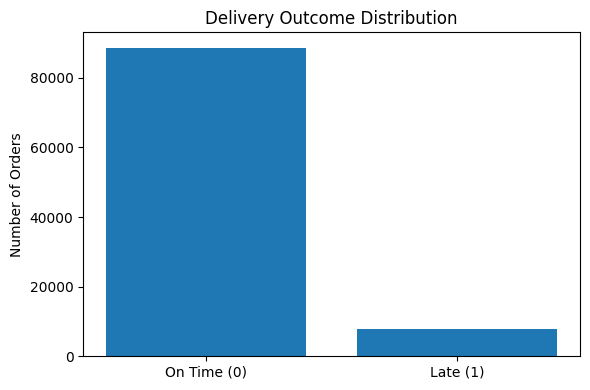

In [12]:
import matplotlib.pyplot as plt

target_counts = ml_table["is_late"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["On Time (0)", "Late (1)"], target_counts.values)
plt.title("Delivery Outcome Distribution")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [14]:
# Numerical columns
numeric_cols = train.select_dtypes(include=["number"]).columns.tolist()

print("Number of numerical columns:", len(numeric_cols))
print(numeric_cols)

# Descriptive statistics
numeric_summary = train[numeric_cols].describe().T

numeric_summary

NameError: name 'train' is not defined

In [15]:
# Create the EDA dataset from the ML table
train = ml_table.copy()

print("Initial shape:", train.shape)

Initial shape: (96470, 33)


In [16]:
print("is_late" in train.columns)
print(train["is_late"].value_counts())

True
is_late
0    88644
1     7826
Name: count, dtype: int64


In [17]:
print([x for x in globals() if not x.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'plt', 'ml_table', 'i', 'col', 'date_columns', 'status_analysis', 'missing_summary', 'date_summary', 'recalculated_is_late', 'target_counts', 'train']


In [20]:
print("Number of columns:", len(train.columns))
print("Unique columns:", train.columns.nunique())

print("\nDuplicate column names:")
print(train.columns[train.columns.duplicated()].tolist())

Number of columns: 33
Unique columns: 33

Duplicate column names:
[]


In [21]:
print("is_late occurrences:", (train.columns == "is_late").sum())

is_late occurrences: 1


In [28]:
# Identify numeric columns directly from the training data
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()

# Make sure the target is not included in the feature list
numeric_features = [
    col for col in numeric_cols
    if col != "is_late"
]

# Calculate correlations with the target
corr_with_target = (
    train[numeric_features + ["is_late"]]
    .corr()["is_late"]
    .drop("is_late")
)

# Sort by absolute correlation strength
corr_with_target = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
)

corr_with_target.to_frame(name="correlation_with_is_late")

,correlation_with_is_late
longitude,0.074576
latitude,0.057260
mean_freight_value,0.042237
unique_sellers,-0.027901
total_freight_value,0.025328
customer_zip_code_prefix,0.024191
geolocation_zip_code_prefix,0.024154
mean_product_weight_g,0.023738
unique_products,-0.022089
mean_item_price,0.021348


<Figure size 800x500 with 0 Axes>

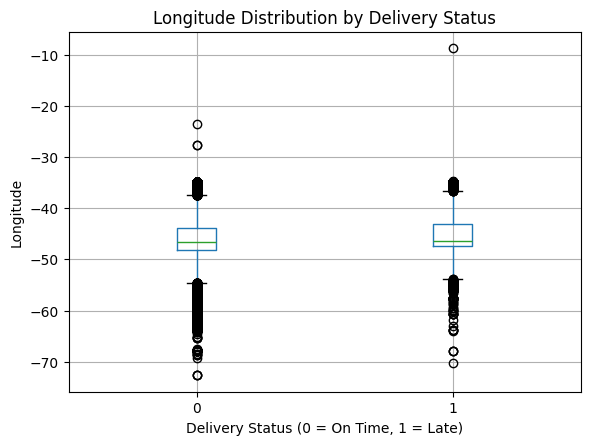

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

train.boxplot(
    column="longitude",
    by="is_late"
)

plt.title("Longitude Distribution by Delivery Status")
plt.suptitle("")
plt.xlabel("Delivery Status (0 = On Time, 1 = Late)")
plt.ylabel("Longitude")

plt.show()

<Figure size 800x500 with 0 Axes>

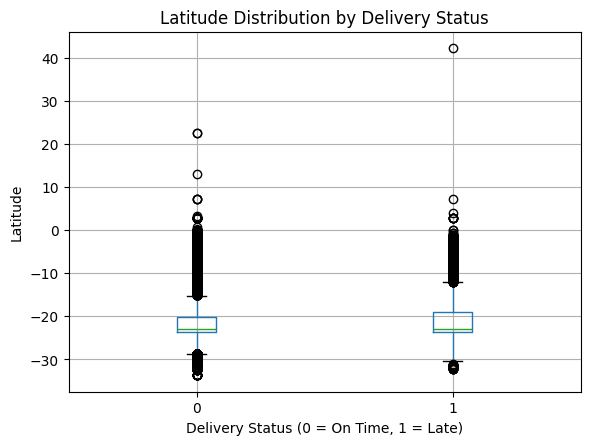

In [30]:
plt.figure(figsize=(8, 5))

train.boxplot(
    column="latitude",
    by="is_late"
)

plt.title("Latitude Distribution by Delivery Status")
plt.suptitle("")
plt.xlabel("Delivery Status (0 = On Time, 1 = Late)")
plt.ylabel("Latitude")

plt.show()

<Figure size 800x500 with 0 Axes>

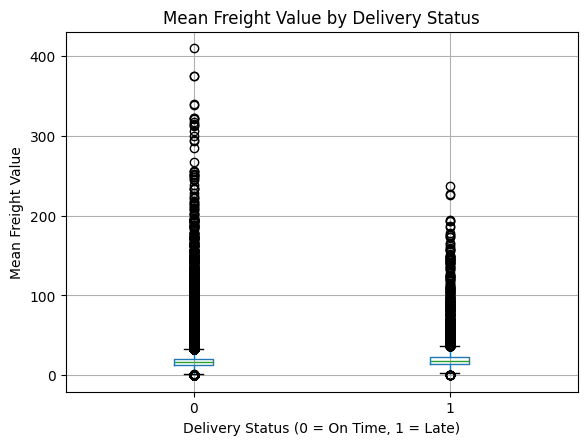

In [31]:
plt.figure(figsize=(8, 5))

train.boxplot(
    column="mean_freight_value",
    by="is_late"
)

plt.title("Mean Freight Value by Delivery Status")
plt.suptitle("")
plt.xlabel("Delivery Status (0 = On Time, 1 = Late)")
plt.ylabel("Mean Freight Value")

plt.show()

In [32]:
categorical_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
for col in categorical_cols:
    print(col)

Categorical columns:
order_id
customer_id
order_status
customer_unique_id
customer_city
customer_state
city
state


In [33]:
id_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

categorical_features = [
    col for col in categorical_cols
    if col not in id_columns
]

print("Categorical features:")
print(categorical_features)

Categorical features:
['order_status', 'customer_city', 'customer_state', 'city', 'state']


In [34]:
categorical_summary = pd.DataFrame({
    "unique_values": train[categorical_features].nunique(),
    "missing_values": train[categorical_features].isna().sum()
}).sort_values("unique_values", ascending=False)

categorical_summary

,unique_values,missing_values
city,4167,264
customer_city,4085,0
customer_state,27,0
state,27,264
order_status,1,0


In [35]:
customer_state_late = (
    train.groupby("customer_state")["is_late"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "late_rate"})
    .sort_values("late_rate", ascending=False)
)

customer_state_late

,count,late_rate
customer_state,,
AL,397,0.239295
MA,717,0.196653
PI,476,0.159664
CE,1279,0.153245
SE,335,0.152239
BA,3256,0.140356
RJ,12350,0.134737
TO,274,0.127737
PA,946,0.123679


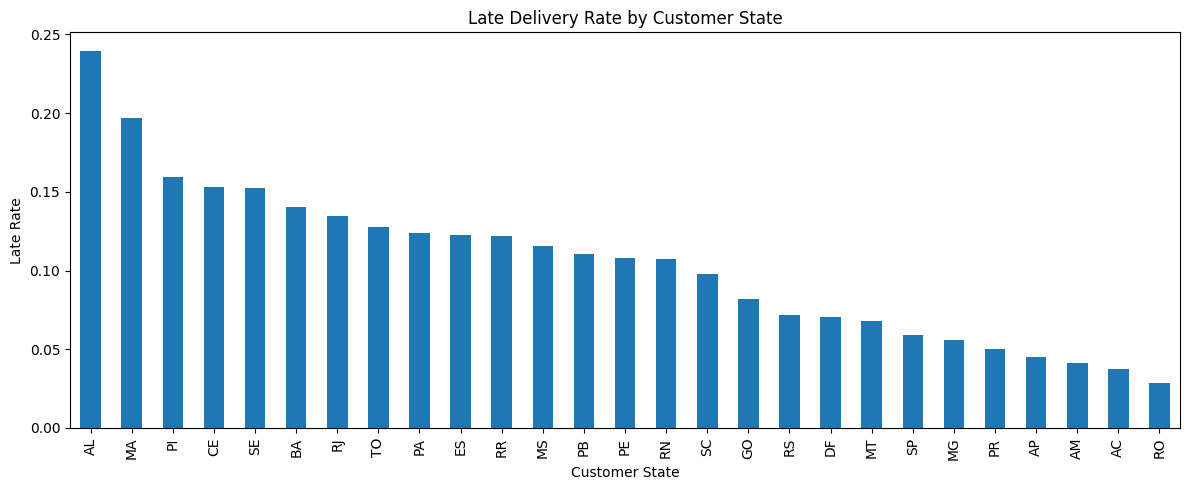

In [36]:
customer_state_late["late_rate"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Rate")

plt.tight_layout()
plt.show()

In [37]:
seller_state_late = (
    train.groupby("state")["is_late"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "late_rate"})
    .sort_values("late_rate", ascending=False)
)

seller_state_late

,count,late_rate
state,,
AL,396,0.239899
MA,714,0.194678
PI,473,0.158562
CE,1275,0.153725
SE,334,0.152695
BA,3248,0.139470
RJ,12337,0.134879
TO,273,0.128205
PA,944,0.123941


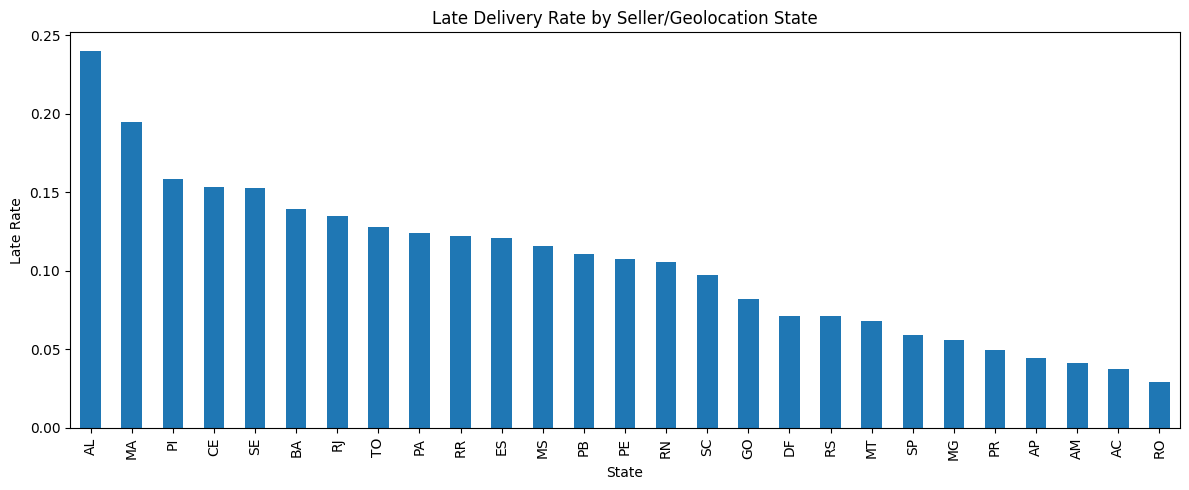

In [38]:
seller_state_late["late_rate"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Late Delivery Rate by Seller/Geolocation State")
plt.xlabel("State")
plt.ylabel("Late Rate")

plt.tight_layout()
plt.show()

In [39]:
train["customer_city"].value_counts().head(20)

customer_city
sao paulo                15045
rio de janeiro            6601
belo horizonte            2697
brasilia                  2071
curitiba                  1489
campinas                  1406
porto alegre              1341
salvador                  1188
guarulhos                 1143
sao bernardo do campo      911
niteroi                    825
santo andre                778
osasco                     724
santos                     700
sao jose dos campos        667
goiania                    660
fortaleza                  618
sorocaba                   609
recife                     593
florianopolis              556
Name: count, dtype: int64

In [40]:
train["city"].value_counts().head(20)

city
sao paulo                12805
rio de janeiro            6592
belo horizonte            2697
são paulo                 2238
curitiba                  1489
brasilia                  1443
campinas                  1406
porto alegre              1341
salvador                  1185
guarulhos                 1143
sao bernardo do campo      808
osasco                     724
santos                     700
santo andre                631
fortaleza                  618
sorocaba                   609
recife                     593
niteroi                    567
goiania                    543
sao jose dos campos        542
Name: count, dtype: int64

In [41]:
customer_city_counts = train["customer_city"].value_counts()

print(
    "Customer cities appearing only once:",
    (customer_city_counts == 1).sum()
)

print(
    "Customer cities appearing fewer than 10 times:",
    (customer_city_counts < 10).sum()
)

Customer cities appearing only once: 1138
Customer cities appearing fewer than 10 times: 3146


In [42]:
train["purchase_month"] = (
    train["order_purchase_timestamp"].dt.month
)

monthly_late = (
    train.groupby("purchase_month")["is_late"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "late_rate"})
)

monthly_late

,count,late_rate
purchase_month,,
1,7819,0.062284
2,8208,0.134137
3,9549,0.171536
4,9101,0.059554
5,10294,0.066446
6,9231,0.022099
7,10028,0.040786
8,10544,0.075778
9,4151,0.052277


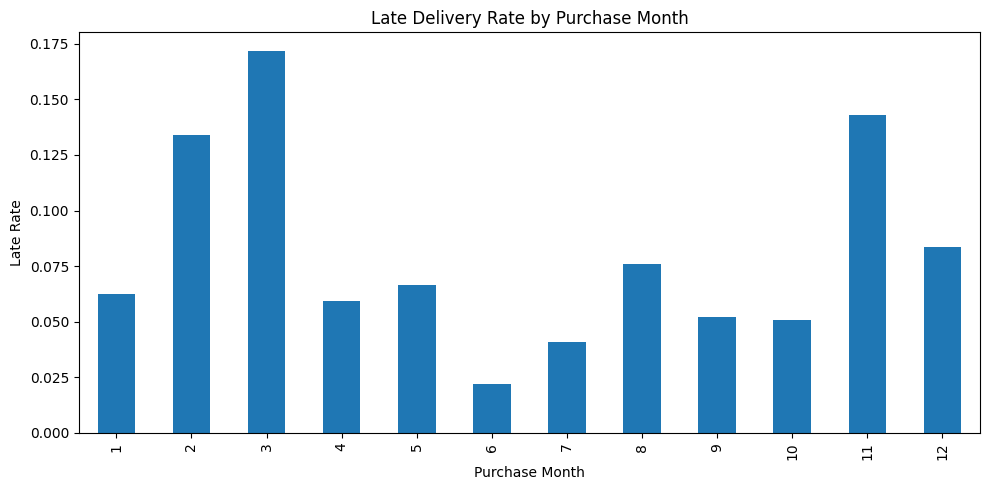

In [43]:
monthly_late["late_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Late Delivery Rate by Purchase Month")
plt.xlabel("Purchase Month")
plt.ylabel("Late Rate")

plt.tight_layout()
plt.show()

In [44]:
train["purchase_dayofweek"] = (
    train["order_purchase_timestamp"].dt.dayofweek
)

weekday_late = (
    train.groupby("purchase_dayofweek")["is_late"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "late_rate"})
)

weekday_late

,count,late_rate
purchase_dayofweek,,
0,15701,0.090504
1,15502,0.084892
2,15074,0.078015
3,14322,0.075688
4,13684,0.084478
5,10555,0.075983
6,11632,0.074880


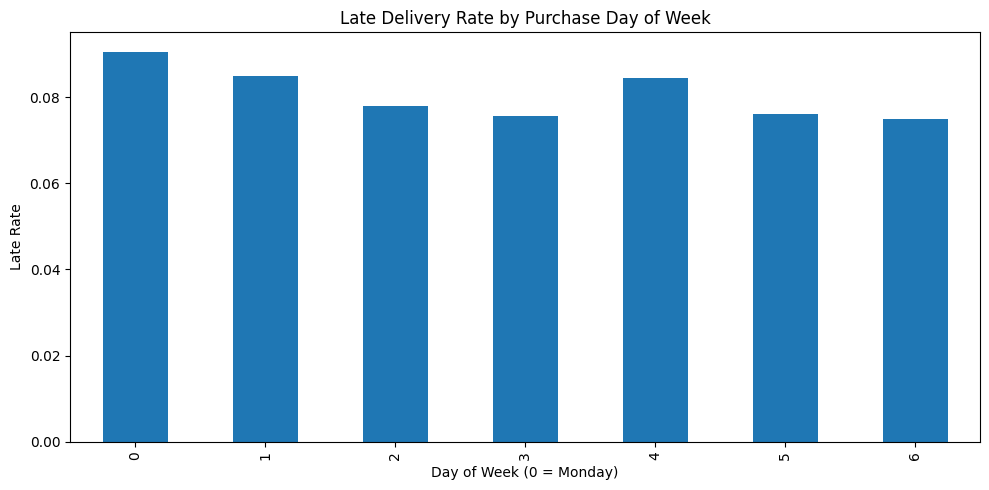

In [45]:
weekday_late["late_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Late Delivery Rate by Purchase Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Late Rate")

plt.tight_layout()
plt.show()

In [46]:
train["delivery_days"] = (
    train["order_delivered_customer_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

In [47]:
train.groupby("is_late")["delivery_days"].describe()

,count,mean,std,min,25%,50%,75%,max
is_late,,,,,,,,
0,88644.0,10.88426,6.191607,0.533414,6.363330,9.727442,14.180373,70.213611
1,7826.0,31.51889,17.259608,2.129537,22.354838,29.154659,37.945159,209.628611


In [48]:
train["estimated_days_from_purchase"] = (
    train["order_estimated_delivery_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

In [49]:
import os

os.makedirs("artifacts/eda", exist_ok=True)

print("EDA artifact folder created.")

EDA artifact folder created.


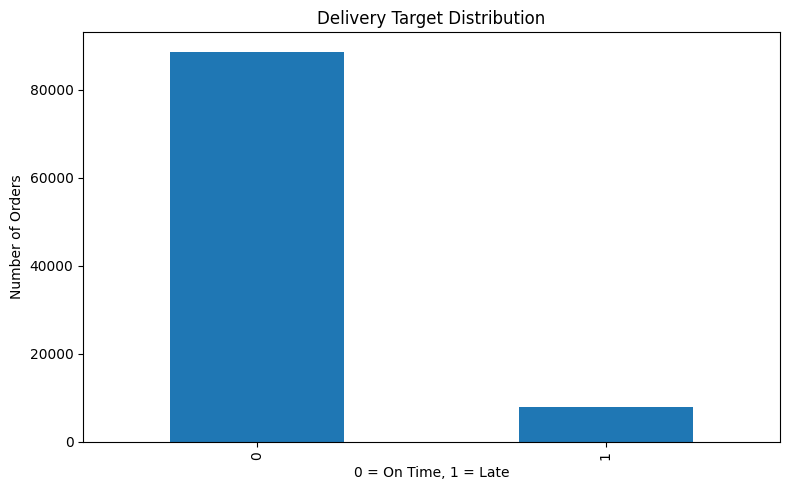

In [50]:
plt.figure(figsize=(8, 5))

train["is_late"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Delivery Target Distribution")
plt.xlabel("0 = On Time, 1 = Late")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "artifacts/eda/target_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# EDA Findings

## Target
- The dataset contains 96,470 delivered orders with known delivery outcomes.
- 88,644 orders (91.89%) were delivered on time.
- 7,826 orders (8.11%) were late.
- The target is imbalanced, so accuracy alone should not be used to evaluate the model.

## Numerical Features
- No numerical feature showed a strong linear correlation with late delivery.
- Longitude (0.075) and latitude (0.057) had the strongest numerical correlations with the target, although the relationships were weak.
- Mean freight value (0.042) also showed a weak positive association.
- Several order-value and product-related variables showed small differences between late and on-time orders.
- Outliers were investigated and were not automatically removed because extreme values may represent legitimate orders.

## Categorical Features
- Customer and seller/geolocation states show variation in late-delivery rates.
- City variables have high cardinality and contain many rare categories.
- State-level features appear more practical than raw city variables for modeling.

## Date Features
- Monthly late-delivery rates vary over time, indicating possible seasonality.
- Purchase weekday was investigated for differences in late-delivery rates.
- Actual delivery duration was examined for EDA but will NOT be used as a predictive feature because it is only known after delivery.
- The estimated delivery window is available before delivery and may be considered as a predictive feature.

## Feature Decisions
Potential predictive features include:
- customer_state
- state / seller geography
- latitude
- longitude
- freight-related features
- product/order value features
- purchase-time features
- estimated delivery window

Identifiers such as order_id, customer_id, and customer_unique_id will not be used as predictive features.

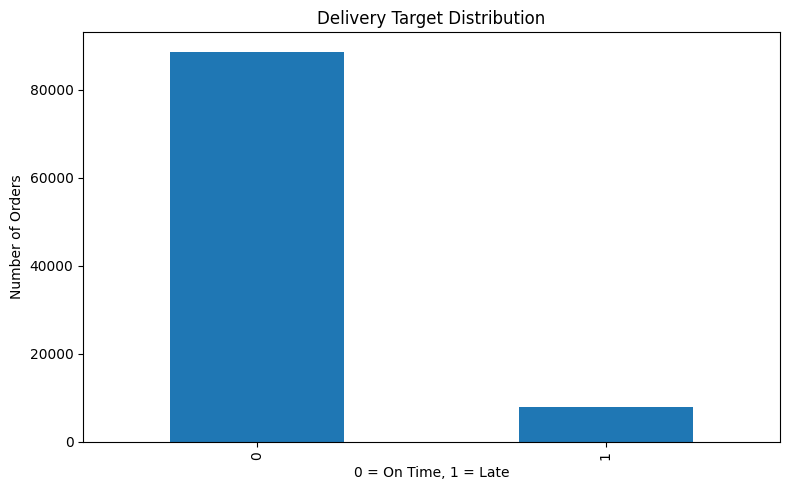

In [51]:
plt.figure(figsize=(8, 5))

train["is_late"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Delivery Target Distribution")
plt.xlabel("0 = On Time, 1 = Late")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "artifacts/eda/target_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()